## Setup

In [1]:
%load_ext autoreload
%autoreload 2

# Other useful imports
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.signal as signal
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA, FastICA
import time
from scipy.signal import welch
from IPython.display import clear_output
import scipy.stats as stats

# Spyeeg import
from spyeeg.generate import simulate_channels, simulate_multisensory_channels, simulate_continuous_stimuli, simulate_PAC
import spyeeg.models as models


Weights have incoherent shape relative to number of features, set to equal weights


(0.0, 10.0)

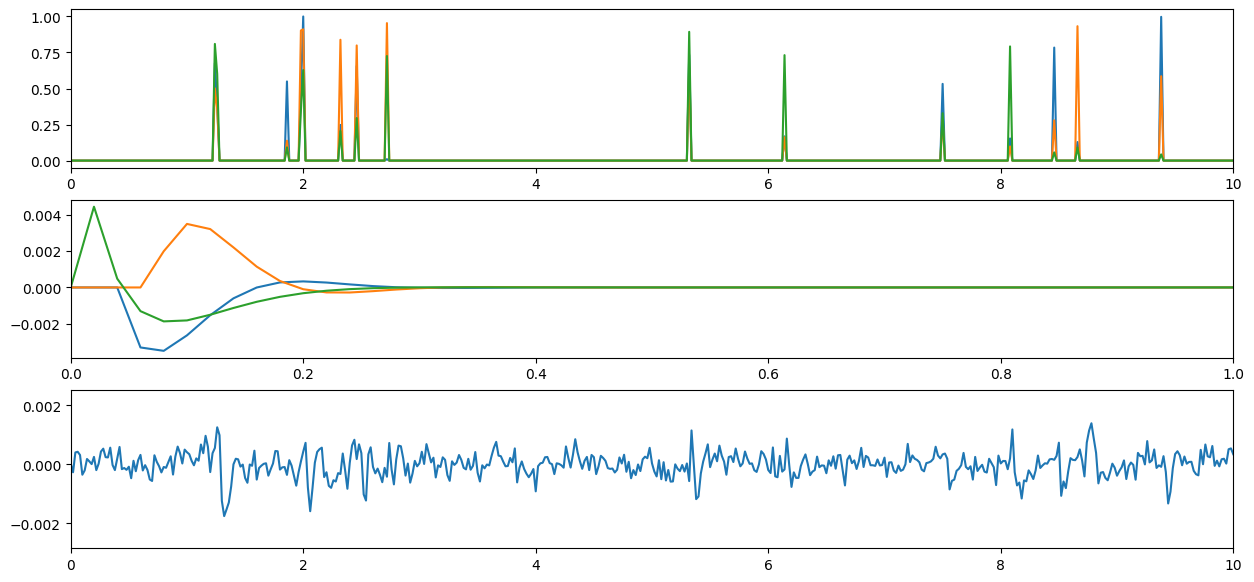

In [69]:
fs = 50
n_feat = 3
n_channels = 1
T = 600
time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,  
                                                              stim_type = 'discrete', n_pulse = T * 2, 
                                                              impulse_freqs = [1,10], decreasing_rates = [10,25], delays = [0.03,0.1],
                                                              weights_feat = [], weights_channel = [1,5],
                                                              compression_factor = 1, share_impulse = True,
                                                              snr_db = 0, beta_noise = 0.4, #0 = white, 1 = pink, 2 = red
                                                              random_seed = 0, scale_data = False)

fig, ax = plt.subplots(3,figsize = (15,7), sharex = False)
ax[0].plot(time_array,X)
for i in range(n_feat):
    for j in range(n_channels):
        ax[1].plot(time_array,impulse_responses[i,j])
ax[2].plot(time_array,Y)
ax[0].set_xlim([0,10])
ax[1].set_xlim([0,1])
ax[2].set_xlim([0,10])

In [70]:
from spyeeg.models.rERP import ERPEstimator

In [71]:
scores.shape

(5, 65, 1, 20)

In [74]:
tmin, tmax = -.3, 1
alphas = np.logspace(-5,5,20)

Y = scale(Y)
erp = ERPEstimator(tmin = tmin, tmax = tmax, srate = fs, alpha = alphas)
scores = erp.xval_eval(X,Y, drop_overlap = False, events_type= 'single',
                      scalex = False, scaley = False)

Training/Evaluating fold 1/5
Training/Evaluating fold 2/5
Training/Evaluating fold 3/5
Training/Evaluating fold 4/5
Training/Evaluating fold 5/5
Fitting full model...


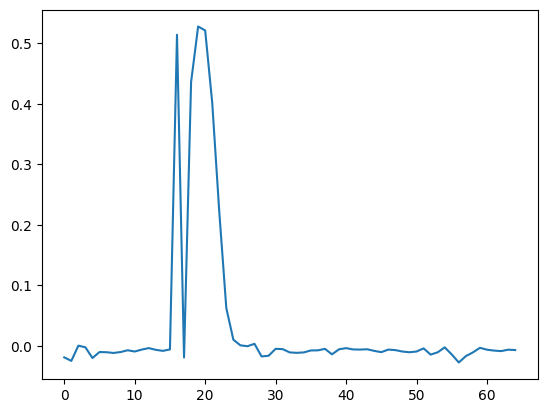

In [75]:
plt.plot(scores[:,:,0,:].mean(0).max(-1))